# EDA 13: TCGA Clinical Context

## Purpose

TCGA contains information from people with cancer, while DepMap contains laboratory-grown cell lines. Patients and cell lines are different biological axes and must never be joined as if they were the same sample. The current TCGA table contains clinical cohort information only; it does not yet contain patient-level mutation, copy-number, or expression states for queried genes.

## Column dictionary

| Column | Meaning | Project use |
| --- | --- | --- |
| `patient_id`, `gdc_case_id` | TCGA submitter and GDC case identifiers. | Patient-axis keys; never model IDs. |
| `tcga_project_id`, `tcga_project_name` | TCGA cancer cohort. | Selects disease-specific validation cohorts. |
| `primary_site`, `disease_type`, `primary_diagnosis` | Tumour location and diagnosis. | Clinical/disease context. |
| `vital_status`, `days_to_death`, `days_to_last_follow_up` | Survival/follow-up information. | Future outcome context with censoring handled properly. |
| `tumor_stage`, `age_at_diagnosis` | Stage and age in days. | Clinical covariates; often incomplete. |
| `source` | Retrieval provenance. | Keeps GDC origin visible. |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown,display
pd.set_option('display.max_columns',100); pd.set_option('display.max_rows',100); sns.set_theme(style='whitegrid')
def find_root(s):
    for c in (s,*s.parents):
        if (c/'data'/'depmap_24Q4'/'architecture'/'model_master.csv').exists(): return c
    raise FileNotFoundError('Run inside az-team25.')
ROOT=find_root(Path.cwd().resolve()); DATA=ROOT/'data'; CORE=DATA/'depmap_24Q4'; EXT=DATA/'external'
master=pd.read_csv(CORE/'architecture'/'model_master.csv',low_memory=False)

tcga=pd.read_csv(EXT/'tcga_gdc'/'derived'/'tcga_patient_master.csv',low_memory=False); print(tcga.shape); display(tcga.head())

(11428, 13)


,patient_id,gdc_case_id,tcga_project_id,tcga_project_name,primary_site,disease_type,vital_status,days_to_death,days_to_last_follow_up,primary_diagnosis,tumor_stage,age_at_diagnosis,source
0,TCGA-E9-A5FL,e3935ce4-64d3-4a66-ba11-d308b844b410,TCGA-BRCA,Breast Invasive Carcinoma,Breast,Complex Epithelial Neoplasms,Alive,NaN,NaN,NaN,NaN,NaN,"GDC cases API, TCGA program"
1,TCGA-A2-A1G4,e3b555aa-7f0a-49c6-9b13-182c61a144c1,TCGA-BRCA,Breast Invasive Carcinoma,Breast,Ductal and Lobular Neoplasms,Alive,NaN,NaN,NaN,NaN,NaN,"GDC cases API, TCGA program"
2,TCGA-BH-A0HF,17ca61a2-607a-45ff-88fa-ef72e80bf891,TCGA-BRCA,Breast Invasive Carcinoma,Breast,Ductal and Lobular Neoplasms,Alive,NaN,NaN,NaN,NaN,NaN,"GDC cases API, TCGA program"
3,TCGA-AR-A1AS,7d681cc6-689d-41c8-9e84-e13733089ec9,TCGA-BRCA,Breast Invasive Carcinoma,Breast,Ductal and Lobular Neoplasms,Alive,NaN,NaN,NaN,NaN,NaN,"GDC cases API, TCGA program"
4,TCGA-D8-A13Y,17f275c1-a0d4-487d-8f02-ea279584b4cd,TCGA-BRCA,Breast Invasive Carcinoma,Breast,Ductal and Lobular Neoplasms,Alive,NaN,NaN,NaN,NaN,NaN,"GDC cases API, TCGA program"


## 1. Patient grain, projects, and completeness

We verify one row per patient and measure missing clinical fields by project.

In [2]:
audit=pd.DataFrame([{'rows':len(tcga),'unique_patient_ids':tcga.patient_id.nunique(),'duplicate_patient_ids':int(tcga.patient_id.duplicated().sum()),'projects':tcga.tcga_project_id.nunique()}]); display(audit); assert tcga.patient_id.is_unique
missing=pd.DataFrame({'missing_n':tcga.isna().sum(),'missing_pct':100*tcga.isna().mean(),'unique':tcga.nunique(dropna=True)}).sort_values('missing_pct',ascending=False); display(missing)
projects=tcga.groupby(['tcga_project_id','tcga_project_name']).agg(patients=('patient_id','size'),alive=('vital_status',lambda x:x.eq('Alive').sum()),dead=('vital_status',lambda x:x.eq('Dead').sum())).sort_values('patients',ascending=False); display(projects)

,rows,unique_patient_ids,duplicate_patient_ids,projects
0,11428,11428,0,33


,missing_n,missing_pct,unique
days_to_last_follow_up,11428,100.000000,0
primary_diagnosis,11428,100.000000,0
tumor_stage,11428,100.000000,0
age_at_diagnosis,11428,100.000000,0
days_to_death,7813,68.367168,1672
vital_status,127,1.111306,4
patient_id,0,0.000000,11428
gdc_case_id,0,0.000000,11428
tcga_project_id,0,0.000000,33
tcga_project_name,0,0.000000,33


,,patients,alive,dead
tcga_project_id,tcga_project_name,,,
TCGA-BRCA,Breast Invasive Carcinoma,1098,945,152
TCGA-GBM,Glioblastoma Multiforme,617,102,492
TCGA-OV,Ovarian Serous Cystadenocarcinoma,608,236,349
TCGA-LUAD,Lung Adenocarcinoma,585,334,188
TCGA-UCEC,Uterine Corpus Endometrial Carcinoma,560,457,91
TCGA-KIRC,Kidney Renal Clear Cell Carcinoma,537,360,177
TCGA-HNSC,Head and Neck Squamous Cell Carcinoma,528,304,224
TCGA-LGG,Brain Lower Grade Glioma,516,389,126
TCGA-THCA,Thyroid Carcinoma,507,491,16


### What this means for the project

TCGA-BRCA patients and breast cell lines can be compared at the cancer-type level, but patient IDs cannot be joined to `model_id`. Any future tumour validation needs a separate patient-gene table and a clearly selected cancer project.

## 2. Clinical distributions and missingness by cohort

Clinical fields differ in completeness across cancer projects, so missing follow-up or stage cannot be treated as a healthy or early-stage outcome.

,count,mean,std,min,25%,50%,75%,max
age_years,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
follow_up_days,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
death_days,3615.0,845.406362,943.967796,0.0,273.0,546.0,1092.5,10870.0


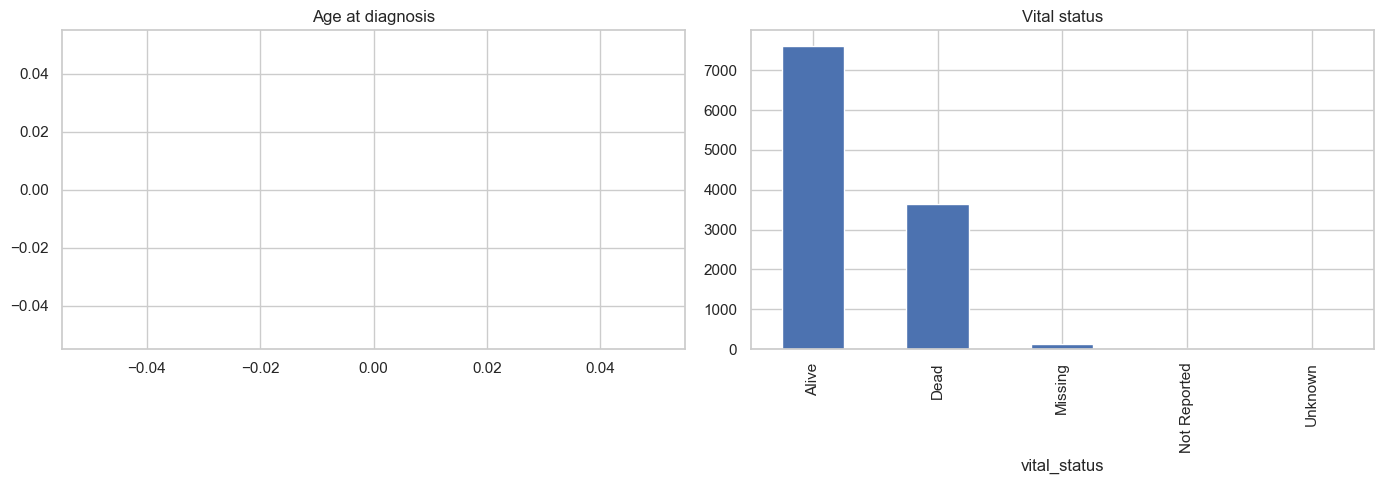

,tumor_stage,age_at_diagnosis,days_to_last_follow_up,primary_diagnosis
tcga_project_id,,,,
TCGA-ACC,100.0,100.0,100.0,100.0
TCGA-BLCA,100.0,100.0,100.0,100.0
TCGA-BRCA,100.0,100.0,100.0,100.0
TCGA-CESC,100.0,100.0,100.0,100.0
TCGA-CHOL,100.0,100.0,100.0,100.0
TCGA-COAD,100.0,100.0,100.0,100.0
TCGA-DLBC,100.0,100.0,100.0,100.0
TCGA-ESCA,100.0,100.0,100.0,100.0
TCGA-GBM,100.0,100.0,100.0,100.0


In [3]:
tcga['age_years']=pd.to_numeric(tcga.age_at_diagnosis,errors='coerce')/365.25; tcga['follow_up_days']=pd.to_numeric(tcga.days_to_last_follow_up,errors='coerce'); tcga['death_days']=pd.to_numeric(tcga.days_to_death,errors='coerce')
display(tcga[['age_years','follow_up_days','death_days']].describe().T)
fig,axes=plt.subplots(1,2,figsize=(14,5)); sns.histplot(tcga.age_years.dropna(),bins=40,ax=axes[0]); axes[0].set_title('Age at diagnosis'); tcga.vital_status.fillna('Missing').value_counts().plot.bar(ax=axes[1]); axes[1].set_title('Vital status'); plt.tight_layout(); plt.show()
project_missing=tcga.groupby('tcga_project_id')[['tumor_stage','age_at_diagnosis','days_to_last_follow_up','primary_diagnosis']].apply(lambda x:100*x.isna().mean())
display(project_missing.round(1))

### What this means for the project

Survival analysis must account for patients who were still alive at last follow-up; they are not known to have survived forever. This notebook describes availability only and does not turn incomplete follow-up into an outcome label.

## Decisions carried into network EDA

- Keep TCGA on a separate patient axis and select cohorts by project/disease.
- Do not claim tumour validation until patient-level gene states are materialised.
- Report clinical-field completeness and censoring rules before outcome analysis.
- Use the current table for cohort design and disease context only.